<a href="https://colab.research.google.com/github/Giovanni-Hessel/FIAP-RNA-2026/blob/main/MLPClassifier_CP2_RNA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [162]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [163]:
#Dados retirado do kaggle, sobre Qualidade dos vinhos: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset
df = pd.read_csv("https://raw.githubusercontent.com/Giovanni-Hessel/FIAP-RNA-2026/refs/heads/main/WineQT.csv")

# Verificando os dados
print(f"Total de registros: {len(df)}")
df.head()

# 'acidez fixa'
# , 'acidez volátil'
# , 'ácido cítrico'
# , 'açúcar residual'
# ,'cloretos'
# , 'dióxido de enxofre livre'
# , 'dióxido de enxofre total'
# , 'densidade'
# ,' pH'
# , 'sulfatos'
# , 'álcool'

Total de registros: 1143


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [164]:
#Transformando o target para um valor de 1 ou 0, para poder aplicar a classificação
#Considerando que os vinhos de qualidade vão maior ou igual a 7.

df['good_quality'] = [1 if x >= 7 else 0 for x in df['quality']]

#Retiro os dois campos de target e o ID que não vai servir para o treinamento
X = df.drop(['quality', 'good_quality','Id'], axis=1)
y = df['good_quality']

print(X.shape)
print(y.shape)

print('Features:', X.columns)
print('Target:', y.name)

(1143, 11)
(1143,)
Features: Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')
Target: good_quality


In [165]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [166]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [167]:
mlps = {}
y_preds = {}

#relu = 0 a n
#tanh = -1 a 1
#logistic = 0 a 1
fn_ativacao = ['relu', 'tanh', 'logistic']

#sgd = Ele atualiza os pesos usando o gradiente de um lote de cada vez
#adam = ajusta a taxa de aprendizado para cada peso individualmente
gradiente_descendente = ['sgd','adam']

for gd in gradiente_descendente:
  for fna in fn_ativacao:

    nome = f'MLP_{fna}_{gd}'

    mlps[nome] = MLPClassifier(hidden_layer_sizes=(10,10)
                                        , activation=fna
                                        ,solver=gd
                                        ,learning_rate_init = 0.01
                                        ,max_iter=1000
                                        ,random_state=42)

    mlps[nome].fit(X_train, y_train)
    y_preds[nome] = mlps[nome].predict(X_test)

    # print(f'Acurracia modelo {nome}:', accuracy_score(y_test, y_preds[nome]))
    print(f'Score modelo {nome}:', mlps[nome].score(X_test, y_test))
    print(classification_report(y_test, y_preds[nome],zero_division=0))

#Recall TP/TP+FN
#precision TN/TN+FP
#f1-score = recall * precision / recall + precision > 0.8
#Acuracia = tp+tn/tp+tn+fp+fn

Score modelo MLP_relu_sgd: 0.8733624454148472
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       201
           1       0.00      0.00      0.00        28

    accuracy                           0.87       229
   macro avg       0.44      0.50      0.47       229
weighted avg       0.77      0.87      0.82       229

Score modelo MLP_tanh_sgd: 0.8646288209606987
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       201
           1       0.36      0.14      0.21        28

    accuracy                           0.86       229
   macro avg       0.63      0.55      0.57       229
weighted avg       0.83      0.86      0.84       229

Score modelo MLP_logistic_sgd: 0.8777292576419214
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       201
           1       0.00      0.00      0.00        28

    accuracy                           0

Notas:
* Olhando os resultados, a combinação da função de ativação "Relu" + Gradiente Descendente "Adam" comparado com os demais foi o que mais performou, logo escolheria ele como modelo para este caso.

* Percebesse que a Gradiente Descendente SGD não é o ideal para esse caso, pois ele atualiza os pesos em blocos, diferente do ADAM que atualiza a taxa de aprendizado para cada peso, e isso acontece também porque os dados são muito desproporcionais entre 0 e 1, então mesmo sempre colocando 0 como resposta da previsão ainda fica com um score alto (maior que 0.8).

* Testamos os modelos usando a coluna quality diretamente, como são muitas saidas, acredito que modelo de classificação não seja o ideal para este caso.



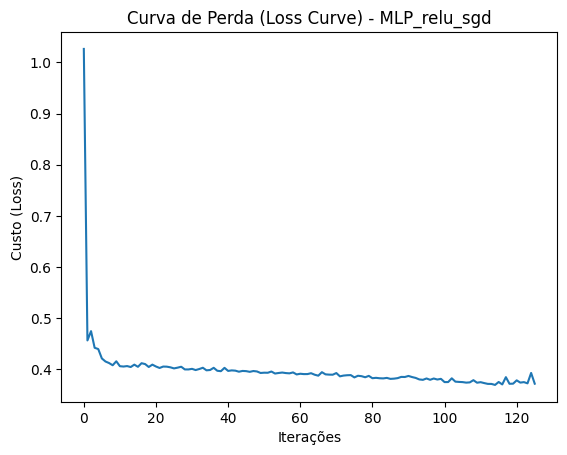

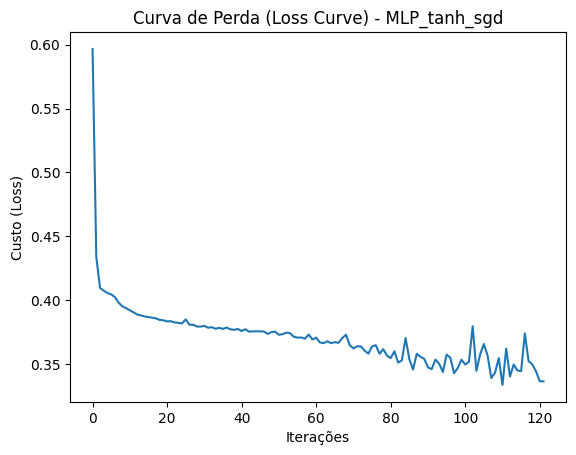

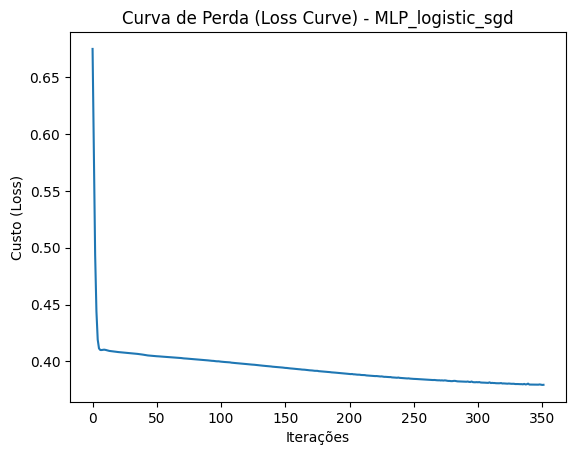

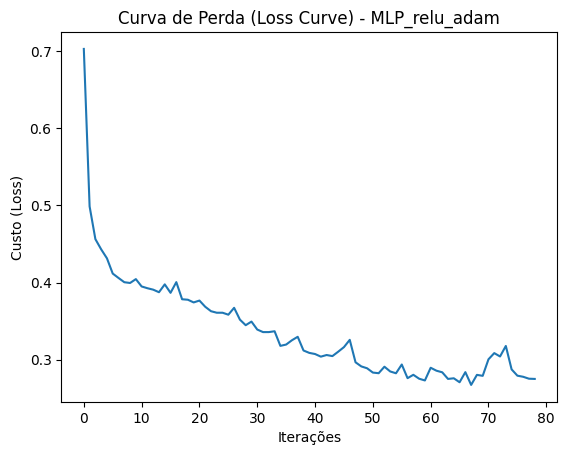

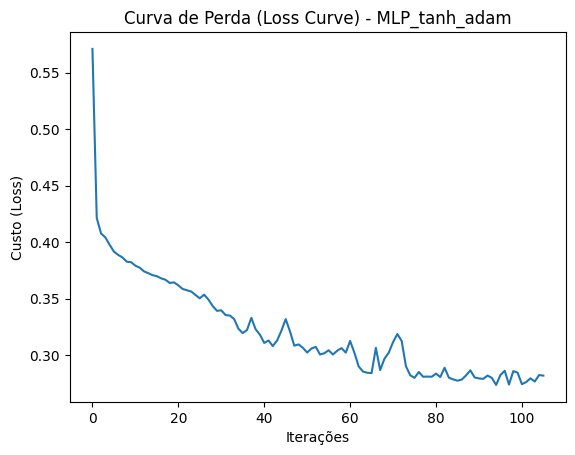

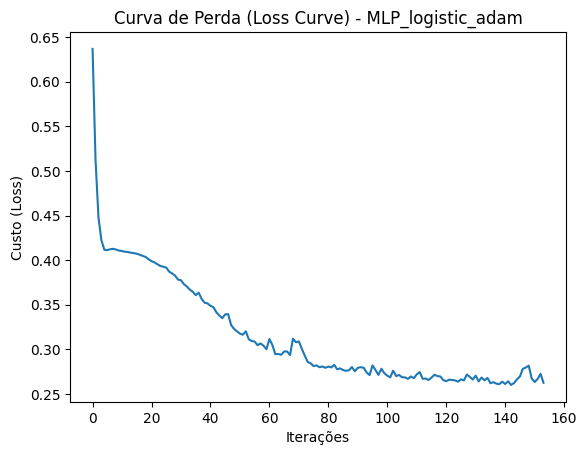

In [168]:

for mlp in mlps:
  plt.plot(mlps[mlp].loss_curve_)
  plt.title(f'Curva de Perda (Loss Curve) - {mlp}')
  plt.xlabel('Iterações')
  plt.ylabel('Custo (Loss)')
  plt.show()